<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/KMeans%26Agglo_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Case Study For CLustering -- diamonds.csv
--- Preprocess
---  

case study for clustering :: diamonds.csv

# Aim of case study

- Preprocess the data

- Find the best K for k means using Lbow method

- Draw dendrogram on first 500 rows of data, find best K

- Apply agglomerative clustering

- Calculate silhoutte score for KMeans and Agglomarative clustering

- Change the linkage type in agglomarative clustering and compare silhoutte score

- Change K and compare silhoutte score



In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('diamonds.csv')
df.shape

(53940, 11)

In [3]:
print(df.columns)
print(df.dtypes)

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object


In [4]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.drop('Unnamed: 0',inplace=True,axis=1)
df.isna().sum()
df.drop_duplicates(inplace=True)
df.shape

(53794, 10)

In [6]:
print(df['cut'].unique())
print(df['color'].unique())
print(df['clarity'].unique())
# multiple nominal columns -- using encoding --OHE

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [7]:
df_ohe = pd.get_dummies(df)
df_ohe.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Fair',
       'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D',
       'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J',
       'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1',
       'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='object')

Find the best K for KMeans using l-bow method

In [8]:
from sklearn.cluster import KMeans

X = df_ohe

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test = train_test_split(X,test_size=0.3,random_state=101)

In [10]:
inertia_values = []
for k in range(2,11):
    mykmeans = KMeans(k,random_state=101)
    mykmeans.fit(X_train)
    inertia_values.append(mykmeans.inertia_)

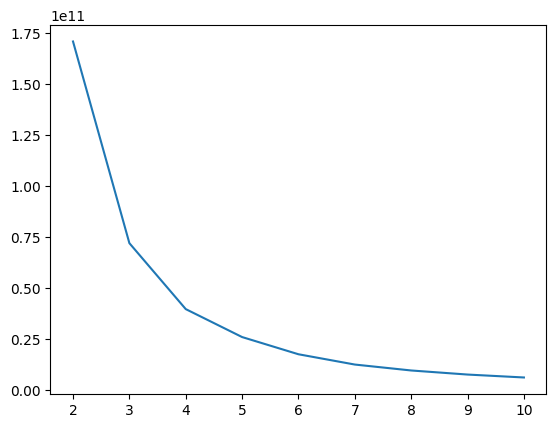

In [11]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values) # looking for angle close to 90

In [12]:
## angle close to 90 for 3 / 4 .. Hence try n_cluster = 3 and 4 and compare thier silouhette scores

In [13]:
from sklearn.metrics import silhouette_score

km = KMeans(n_clusters=3,max_iter=100,random_state=101)
km.fit(X_train)
y_pred = km.predict(X_test)
print(silhouette_score(X_test,y_pred))


0.660617888137561


In [14]:
'''from sklearn.metrics import silhouette_score

km = KMeans(n_clusters=4,max_iter=100,random_state=101)
km.fit(X_train)
y_pred = km.predict(X_test)
print(silhouette_score(X_test,y_pred))
'''

'from sklearn.metrics import silhouette_score\n\nkm = KMeans(n_clusters=4,max_iter=100,random_state=101)\nkm.fit(X_train)\ny_pred = km.predict(X_test)\nprint(silhouette_score(X_test,y_pred))\n'

In [15]:
## n_clusters = 3 is better.

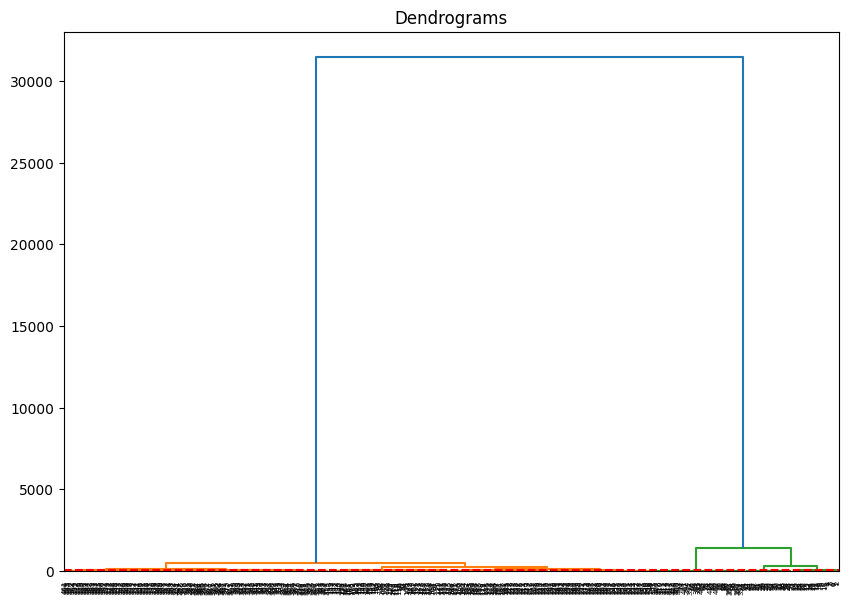

In [16]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='ward'))
plt.axhline(y=50, color='r', linestyle='--')

# from this plot we may infer k to be 2, but this is because we are only taking 500 rows. Plot crashes for 53000 records

Agglomerative Clustering

In [17]:
from sklearn.cluster import AgglomerativeClustering

In [18]:
ac = AgglomerativeClustering(n_clusters=3)
ac.fit(X_train)
y_pred = ac.fit_predict(X_train)

In [19]:
print(silhouette_score(X_train,y_pred))

0.6595678726232308


In [20]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='single')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train) # here taking entire train data i.e all records
print(silhouette_score(X_train,y_pred))

0.18639934826827723


In [22]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='average')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train.loc[:500,:]) # only taking 500 records -- to conserve RAM
print(silhouette_score(X_train.loc[:500,:],y_pred))

0.6429328756113523


In [23]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='complete')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train,y_pred))

0.6478313782235513


In [24]:
# Now try for n = 4 -- no of clusters = 4

In [25]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3)
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train.loc[:500,:]) # only taking 500 records -- to conserve RAM
print(silhouette_score(X_train.loc[:500,:],y_pred))

0.6376728099466384


In [26]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='single')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train.loc[:500,:]) # only taking 500 records -- to conserve RAM
print(silhouette_score(X_train.loc[:500,:],y_pred))

0.274909381611258


In [27]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='average')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train.loc[:500,:]) # only taking 500 records -- to conserve RAM
print(silhouette_score(X_train.loc[:500,:],y_pred))

0.6429328756113523


In [28]:
# Default linkage is -'ward' : trying linkage -- 'single','complete' and 'average'
ac = AgglomerativeClustering(n_clusters=3,linkage='complete')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train.loc[:500,:]) # only taking 500 records -- to conserve RAM
print(silhouette_score(X_train.loc[:500,:],y_pred))

0.5945416868610861
